# Stage 3 – EDA, Step 11: Imbalance (Regression Interpretation, Training Set)

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `09_eda_multivariate.ipynb` (Step 10 – multivariate relationships)

---

## Where we are

Steps 8–10 described the training data and how the features relate to rent. Step 11 asks a different question: **where will a model be weak, and why?**

## What "imbalance" means for a regression problem

In **classification**, imbalance is easy to picture: 99% of emails are normal and 1% are spam, so a lazy model can say "normal" every time and still be 99% accurate. In **regression** (predicting a number, like rent) there are no classes, but the same problem exists in three forms:

| Form | In our data | Why it hurts a model |
|---|---|---|
| **Target imbalance** | Most rents are $750–$1,500; very few are above $4,000 (the long right tail from Step 2). | The model sees few expensive homes, so it learns them poorly and tends to **pull their predictions down** towards typical rents. |
| **Rare categories and rare homes** | Valet parking (108 listings), in-law units (134), 6+ bedrooms (182). | A category's effect is learned from its own listings; with few listings the estimate is noisy. |
| **Geographic imbalance** | Seattle has 1,698 listings; Big Bend has 4. The top 15 states hold 61% of listings. | Predictions for thinly covered places rest on little local evidence. |

Plus one group found in Step 10.7: **student-layout homes** (4+ bedrooms with a bathroom per bedroom), whose advertised "rent" is often the price of **one room**.

## How this step measures the damage: a location-only baseline

Counting listings shows *where* data is thin, but not *how much it matters*. So this notebook builds the simplest reasonable model:

> **predict each listing's rent as the median rent of its region** (falling back to the state median, then the national median, when a region is unseen).

It's evaluated honestly with **grouped cross-validation** on the training set (explained in 11.2), and its errors are broken down by price band, category, region size and student layout. This does two jobs:

1. It shows the **typical error pattern of imbalance** (for example, expensive homes being under-predicted), before any real model exists.
2. It gives the **baseline score every real model must beat**. If LightGBM can't clearly beat "region median", something is wrong. Examiners like to see a baseline.

The test set stays locked: everything here uses the training set only.

## Sections

| Section | Question |
|---|---|
| 11.1 | How unevenly are rents spread over price bands? |
| 11.2 | Location-only baseline with grouped cross-validation |
| 11.3 | Error by price band: which rents does the baseline get wrong? |
| 11.4 | Rare categories and rare homes |
| 11.5 | Geographic imbalance |
| 11.6 | Student-layout homes |
| 11.7 | The error-analysis plan for the final evaluation |
| 11.8 | Log the observations |

> **Viva tip:** "Imbalance in regression means unevenly covered parts of the target and feature space. We measured it by counting, and quantified its effect with a cross-validated location-only baseline, broken down by price band, category, region size and a problem group found in Step 10."

## 11.0 Setup

**What this cell does:** the usual imports and helpers, then it loads the **training set** and adds the columns this notebook needs:

- `log_price`, as in every step since Step 9;
- `price_band`: which **price band** each rent falls in;
- `region_listings` and `region_band`: how many training listings the listing's region has, and which size band that puts it in (under 30, 30–99, 100–499, 500+);
- `student`: True for **student-layout** homes (4+ bedrooms, at least one bathroom per bedroom; Step 10.7).

**New in `utils.py` for this step (add these before running, if you haven't yet):** the band edges and three small helper functions. They live in `utils.py`, not here, because the **final model evaluation (Step 14) must use exactly the same groups**. If they were defined in this notebook, the two could drift apart. The setup cell stops with a clear message if they're missing.

**Why these price bands?** `$250–750`, `$750–1,000`, `$1,000–1,500`, `$1,500–2,500`, `$2,500–4,000`, `$4,000–10,000`. They're **round dollar amounts** a reader understands immediately, narrow where most listings are (so each band is a meaningful group) and wide in the tail (where listings are few). The lower and upper edges are the cleaning limits ($250 rent floor, $10,000 cap).

**How to read the output:** the number of training listings (150,404, as before) and the Step 10 log to confirm the handover. The Step 10 log should contain the **corrected 10.4 wording** if you re-ran notebook 09.

In [10]:
# 11.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

_needed = ["PRICE_BANDS", "REGION_SIZE_BANDS", "STUDENT_LAYOUT_MIN_BEDS", "price_band", "region_size_band",
           "student_layout", "RARE_MIN_COUNT"]
_missing = [n for n in _needed if n not in globals()]
if _missing:
    raise NameError(f"Add these to src/utils.py first (Step 9 and Step 11 blocks): {_missing}")

train = load_train()          # the TRAINING set only; the test set stays locked
train["log_price"] = np.log1p(train["price"])
for col in ["laundry_options", "parking_options"]:
    train[col] = train[col].fillna("missing")      # as the pipeline will treat blanks (Step 3)

region_counts = train["region_url"].value_counts()
train["price_band"] = price_band(train["price"])
train["region_listings"] = train["region_url"].map(region_counts)
train["region_band"] = region_size_band(train["region_url"], region_counts)
train["student"] = student_layout(train)

overall_median = train["price"].median()
print(f"Training listings: {len(train):,}   |   overall median rent: ${overall_median:,.0f}")
print(f"Price bands: {list(train['price_band'].cat.categories)}")
print(f"Region size bands: {list(train['region_band'].cat.categories)}")
print(f"Student-layout homes (>= {STUDENT_LAYOUT_MIN_BEDS} beds, baths >= beds): {train['student'].sum():,}")

def short_region(url):
    # 'https://seattle.craigslist.org' -> 'seattle'
    return url.replace("https://", "").replace(".craigslist.org", "")

show_obs(10)   # Step 10 findings, to confirm the handover

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training listings: 150,404   |   overall median rent: $1,150
Price bands: ['$250-$750', '$750-$1,000', '$1,000-$1,500', '$1,500-$2,500', '$2,500-$4,000', '$4,000-$10,000']
Region size bands: ['0-29', '30-99', '100-499', '500+']
Student-layout homes (>= 4 beds, baths >= beds): 442


,step,observation,evidence,decision
0,10-Multivariate,Strongly correlated feature pairs (|Spearman| ...,10.1 Spearman heatmap,Overlapping features are handled by Ridge (lin...
1,10-Multivariate,Highest VIF 3.72 (cats_allowed); size trio VIF...,10.2 VIF table and coefficient check,No worrying multicollinearity among numeric in...
2,10-Multivariate,Net mutual information top 3: region_url 0.559...,10.3 mutual information vs eta-squared chart,Two independent methods agree on the feature r...
3,10-Multivariate,Size elasticity 0.45 nationally vs 0.49 within...,"10.4 region scatter, bedroom lines, parking table",Size effect grows within regions (region media...
4,10-Multivariate,"Variance of log rent: 31.1% between states, 17...","10.5 decomposition bar, fallback table",Keep region_url (target-encoded) and state (on...
5,10-Multivariate,Within-region size elasticity by state 0.40-0....,"10.6 elasticity bars, type x state heatmap",Size effect is similar across states; type pre...
6,10-Multivariate,Rent per sq ft of one-bath-per-bedroom vs fewe...,"10.7 layout table, wording share, region list",Some large homes appear to be priced per bedro...


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.0 Findings

- **150,404 training listings**, overall median rent **$1,150**, as in Steps 8–10. All Step 9 and Step 11 lines are in `utils.py` (the setup check passed).
- **442 student-layout homes** (4+ bedrooms, at least one bathroom per bedroom), 0.29% of the training set.
- The Step 10 log shows the **corrected 10.4 wording** ("Size effect grows within regions…").
- The message *"The autoreload extension is already loaded"* just means the kernel wasn't restarted before running. It's harmless, but **Restart & Run All** is still the safest habit.

## 11.1 Target imbalance: how are rents spread over the price bands?

**What this cell does:** it counts the training listings in each price band and shows, for each band, its **share of listings**, its **median rent** and the **cumulative share** (the share of listings at or below that band). It draws two charts:

- **left:** the share of listings per band as bars;
- **right:** the histogram of log rent (the scale the models learn on) with the band edges as dashed lines, so you can see how the tail thins out.

It also prints how many times more listings the busiest band has than the emptiest one.

**Why this matters:** a model learns mostly from the bands that hold most listings. When it's trained to minimise the *average* error, a band with 1% of the listings contributes only 1% of the "pressure" on the model. Mistakes there barely hurt the average, so the model doesn't try hard to avoid them.

**How to read the output:**

- **Compare the top band with the middle bands.** If the middle bands each hold 20–30% of listings and the $4,000+ band well under 1%, the tail is thin. That's the regression version of a "minority class".
- **Look at the log histogram.** Step 2 chose `log1p(price)` partly to fix this: on the log scale the distribution is roughly bell-shaped, so the tail is **much less extreme** than on the dollar scale. The log target **reduces** target imbalance; it doesn't remove it.
- **The cumulative share** answers questions like *"what share of listings rent for $1,500 or less?"*, which is useful in the report to describe the market the system serves.

> **Viva point:** "Why not just oversample expensive listings, like SMOTE for classification?" Oversampling changes the population the model thinks it is predicting for. The model would then over-predict ordinary homes. Our approach is to model on the log scale, keep the population as it is, and **report errors per price band**, so any weakness in the tail is visible rather than hidden in an average.

,listings,median_rent,share_%,cumulative_%
price_band,,,,
$250-$750,"22,299",$650,14.8%,14.8%
"$750-$1,000","36,877",$895,24.5%,39.3%
"$1,000-$1,500","51,954","$1,235",34.5%,73.9%
"$1,500-$2,500","31,726","$1,800",21.1%,95.0%
"$2,500-$4,000","6,444","$2,916",4.3%,99.3%
"$4,000-$10,000","1,104","$4,892",0.7%,100.0%


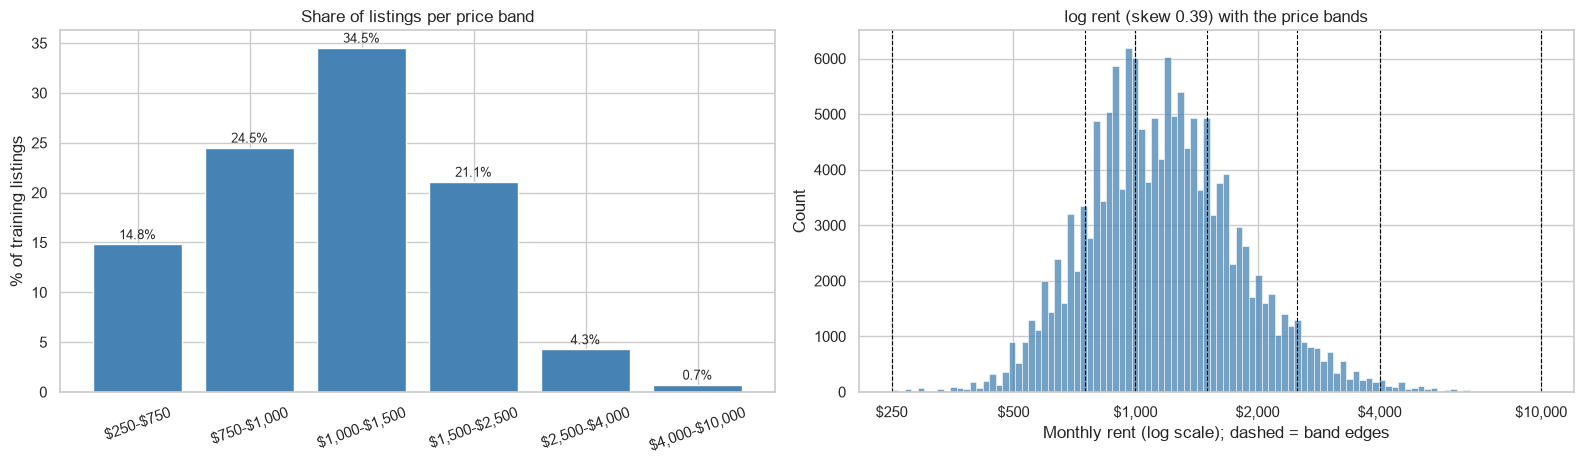

Busiest band $1,000-$1,500 has 47x the listings of the emptiest band $4,000-$10,000
Listings above $2,500: 5.0%   |   above $4,000: 0.73%
Skew: 2.70 in dollars vs 0.39 on the log scale


In [11]:
# 11.1 Listings per price band

bands = train.groupby("price_band", observed=False)["price"].agg(listings="size", median_rent="median")
bands["share_%"] = bands["listings"] / len(train) * 100
bands["cumulative_%"] = bands["share_%"].cumsum()
display(bands.style.format({"listings": "{:,}", "median_rent": "${:,.0f}", "share_%": "{:.1f}%",
                            "cumulative_%": "{:.1f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
axes[0].bar([str(b).replace("$", r"\$") for b in bands.index], bands["share_%"], color="steelblue")   # \$ stops matplotlib reading $...$ as maths
for i, v in enumerate(bands["share_%"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[0].set(ylabel="% of training listings", title="Share of listings per price band")
axes[0].tick_params(axis="x", rotation=20)

sns.histplot(train["log_price"], bins=100, ax=axes[1], color="steelblue")
for edge in PRICE_BANDS:
    axes[1].axvline(np.log1p(edge), color="black", linestyle="--", linewidth=0.8)
ticks = [250, 500, 1000, 2000, 4000, 10000]
axes[1].set_xticks(np.log1p(ticks)); axes[1].set_xticklabels([f"${t:,}" for t in ticks])
axes[1].set(xlabel="Monthly rent (log scale); dashed = band edges",
            title=f"log rent (skew {train['log_price'].skew():.2f}) with the price bands")
plt.tight_layout()
save_fig("11_price_bands")
plt.show()

top_band_share = bands["share_%"].iloc[-1]
busiest, emptiest = bands["listings"].idxmax(), bands["listings"].idxmin()
band_ratio = bands["listings"].max() / max(bands["listings"].min(), 1)
above_2500 = (train["price"] > 2500).mean() * 100
print(f"Busiest band {busiest} has {band_ratio:.0f}x the listings of the emptiest band {emptiest}")
print(f"Listings above $2,500: {above_2500:.1f}%   |   above $4,000: {(train['price'] > 4000).mean() * 100:.2f}%")
print(f"Skew: {train['price'].skew():.2f} in dollars vs {train['log_price'].skew():.2f} on the log scale")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.1 Findings – target imbalance

| Band | Listings | Share | Cumulative | Median rent |
|---|---|---|---|---|
| $250–$750 | 22,299 | 14.8% | 14.8% | $650 |
| $750–$1,000 | 36,877 | 24.5% | 39.3% | $895 |
| $1,000–$1,500 | 51,954 | **34.5%** | 73.9% | $1,235 |
| $1,500–$2,500 | 31,726 | 21.1% | 95.0% | $1,800 |
| $2,500–$4,000 | 6,444 | 4.3% | 99.3% | $2,916 |
| $4,000–$10,000 | 1,104 | **0.7%** | 100% | $4,892 |

- **95% of listings rent for $2,500 or less**, and three-quarters for $1,500 or less. The system mainly serves ordinary rentals, and the report should say so.
- The busiest band ($1,000–$1,500) has **47×** the listings of the $4,000+ band. Only **5.0%** of listings are above $2,500 and **0.73%** above $4,000. That's the regression version of a "minority class".
- **The log target helps a lot, but doesn't remove the tail:** skew **2.70** in dollars vs **0.39** on the log scale.

**Decision:** keep the natural population (no oversampling or weighting), model `log1p(price)`, and report every final metric **per price band**.

## 11.2 A location-only baseline, evaluated with grouped cross-validation

**What this cell does:** it builds the simplest sensible predictor, **"rent = median rent of the listing's region"**, and measures how good it is **without ever letting it see the listing it predicts**.

**Step 1 – cross-validation, in plain words.** We can't judge a model on listings it learned from; it would look better than it really is. So the training set is split into **5 folds** (parts). Five times over, the baseline "learns" region medians from 4 folds and predicts the 5th. At the end, **every listing has one prediction made without it**. These are called **out-of-fold predictions**.

> *Analogy:* a teacher writes five exams from a question bank and each student sits the exam whose questions they never practised.

**Step 2 – why *grouped* (`GroupKFold` on `group_id`)?** Step 7 found that 37% of listings have a close relative (a repost at a different price, or the same description with a small edit). If one copy is in the learning folds and its twin in the predicted fold, the prediction is partly a lookup, and the score is too optimistic. `GroupKFold` keeps every family **in the same fold**. This is the same rule the real models will follow.

**Step 3 – fallbacks.** If a region has no listings in the 4 learning folds, the state median is used; if the state is also missing, the national median. (With 413 regions this is rare, but the code must never fail.)

**Step 4 – the scores.** It reports the baseline's:

- **MAE (mean absolute error)** in dollars: the average size of the mistake. The easiest number to explain ("off by $X on average").
- **RMSE** in dollars: like MAE but punishes large mistakes more, so it's sensitive to the tail.
- **Median absolute % error:** the typical mistake as a percentage of the true rent. It's fair to cheap and expensive homes alike.
- **R² on log rent:** the share of the variation in log rent the baseline reproduces (it should be close to region's η² of 48% from Step 9, a useful cross-check).

It saves these to `reports/baseline_location_only.csv`, so the modelling notebooks can load and compare against them.

**How to read the output:** these numbers are the **bar to clear**. Every model with size, amenities and coordinates must do clearly better. The *pattern* of the baseline's errors (next sections) shows what imbalance does to a model that only knows averages.

> **Viva point:** "Our baseline is the region median, evaluated with grouped 5-fold cross-validation on the training set. It reaches an R² of about [value] on log rent; every model is compared against it."

In [12]:
# 11.2 Out-of-fold region-median baseline

gkf = GroupKFold(n_splits=5)
oof_log = np.full(len(train), np.nan)
fallback_used = 0
for fit_idx, val_idx in gkf.split(train, groups=train["group_id"]):
    fit, val = train.iloc[fit_idx], train.iloc[val_idx]
    region_med = fit.groupby("region_url")["log_price"].median()
    state_med = fit.groupby("state")["log_price"].median()
    pred = val["region_url"].map(region_med)
    fallback_used += int(pred.isna().sum())
    pred = pred.fillna(val["state"].map(state_med)).fillna(fit["log_price"].median())
    oof_log[val_idx] = pred.to_numpy()

train["pred"] = np.expm1(oof_log)
train["err_pct"] = (train["pred"] / train["price"] - 1) * 100      # + = over-predicted, - = under-predicted
train["abs_err"] = (train["pred"] - train["price"]).abs()

r2_log = 1 - ((train["log_price"] - oof_log) ** 2).sum() / ((train["log_price"] - train["log_price"].mean()) ** 2).sum()
baseline = pd.Series({
    "MAE_$": train["abs_err"].mean(),
    "RMSE_$": np.sqrt(((train["pred"] - train["price"]) ** 2).mean()),
    "median_abs_%_error": train["err_pct"].abs().median(),
    "R2_log": r2_log,
    "listings": len(train),
}, name="location-only baseline (region median, GroupKFold 5)")
display(baseline.to_frame().T.style.format({"MAE_$": "${:,.0f}", "RMSE_$": "${:,.0f}", "median_abs_%_error": "{:.1f}%",
                                            "R2_log": "{:.3f}", "listings": "{:,.0f}"}))
baseline.to_frame().T.to_csv(REPORT_DIR / "baseline_location_only.csv", index=False)
print(f"Listings whose region was missing from the learning folds (fallback used): {fallback_used:,}")
print(f"Saved to {REPORT_DIR / 'baseline_location_only.csv'}")

,MAE_$,RMSE_$,median_abs_%_error,R2_log,listings
"location-only baseline (region median, GroupKFold 5)",$318,$518,18.8%,0.468,"150,404"


Listings whose region was missing from the learning folds (fallback used): 0
Saved to C:\Projects\FDM Project\fdm-rental-price\reports\baseline_location_only.csv


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.2 Findings – the baseline to beat

| Metric | Location-only baseline |
|---|---|
| MAE | **$318** |
| RMSE | **$518** |
| Median absolute % error | **18.8%** |
| R² on log rent | **0.468** |

- **Knowing only the region gets you surprisingly far:** the typical error is under 19%, and R² is 0.468.
- **Cross-check:** Step 9 found region η² = 48.1% *in-sample*. The honest, out-of-fold R² is a little lower (46.8%), exactly as it should be: out-of-fold predictions can't use a listing's own rent.
- **RMSE is much larger than MAE** ($518 vs $318): a minority of very large errors (the expensive tail, 11.3) dominate RMSE.
- **No fallback was needed:** every region had listings in every set of learning folds.

**Decision:** these four numbers are the bar. Every model (Ridge, k-NN, Random Forest, LightGBM, MLP) is evaluated with the **same `GroupKFold(5)` on `group_id`** and must clearly beat them. They're saved in `reports/baseline_location_only.csv`.

> **Viva point:** "A region-median baseline, evaluated with grouped cross-validation, has a median error of 18.8% and an R² of 0.47 on log rent. Our models are judged by how much they improve on that."

## 11.3 Error by price band: which rents does the baseline get wrong?

**What this cell does:** it breaks the baseline's errors down **by price band**, in two different ways, and draws the **bias** (the typical signed error) for each band.

**Two error measures per band:**

- **Bias (median signed % error):** is the baseline typically **too high** (+) or **too low** (−) for listings in this band? A good model has a bias near 0 in every band.
- **Median absolute % error:** how big the typical mistake is, regardless of direction.
- (MAE in dollars is shown too, but it naturally grows with rent: a 10% miss is $75 on a $750 rent and $500 on a $5,000 rent.)

**Two ways to group, answering two different questions:**

| Grouped by | Question it answers | Who cares |
|---|---|---|
| **true rent band** | *"For which kinds of homes does the model fail?"* | the developer (where to improve) |
| **predicted rent band** | *"If the model says $X, how far off is it likely to be?"* | the **user of the platform** |

**An important subtlety (a strong viva point): regression to the mean.** When you group by the **true** rent, *every* imperfect model shows the same pattern: cheap homes over-predicted, expensive homes under-predicted. The reason: a listing is in the top band partly *because* it's unusually expensive for its features (a great view, a renovation the data doesn't record). No model can see those hidden reasons, so its prediction falls back towards what is typical. So a slope in this chart is expected; what matters is **how steep** it is, and how much better real models make it.

> *Analogy:* the tallest children in a class usually have parents who are tall, but a bit less tall than the children. Selecting the extremes on the outcome always shows this pull back to the middle.

Grouping by the **predicted** rent doesn't have this built-in pull: a well-behaved model should have a bias near 0 in every **predicted** band. If it doesn't, the model is systematically off for that kind of prediction (for example, "whenever it predicts over $2,500 it's too low").

**How to read the output:**

- **True-band chart:** expect + on the left and − on the right. The size of the bars in the top bands shows how badly a location-only model misses expensive homes.
- **Predicted-band table:** biases near 0 mean that a baseline prediction is fair on average; large biases in the thin bands show where too few listings make predictions unreliable.

**What we'll do about it:** keep the population as it is (no oversampling or weighting now), keep the log target, and **report every final metric per price band** (both groupings). If the final model's top-band errors are clearly unacceptable, sample weights are the fallback to try, and their effect on the other bands must be reported too.

Grouped by TRUE rent band:


,listings,share_%,median_rent,bias_pct,median_abs_pct,MAE
price_band,,,,,,
$250-$750,"22,299",14.8%,$650,+35.7%,35.7%,$272
"$750-$1,000","36,877",24.5%,$895,+10.0%,14.2%,$175
"$1,000-$1,500","51,954",34.5%,"$1,235",-4.7%,14.3%,$212
"$1,500-$2,500","31,726",21.1%,"$1,800",-18.9%,21.9%,$441
"$2,500-$4,000","6,444",4.3%,"$2,916",-33.9%,33.9%,"$1,068"
"$4,000-$10,000","1,104",0.7%,"$4,892",-58.2%,58.2%,"$3,133"


Grouped by PREDICTED rent band:


,listings,share_%,median_rent,bias_pct,median_abs_pct,MAE
predicted_band,,,,,,
$250-$750,"7,819",5.2%,$725,-1.7%,18.4%,$189
"$750-$1,000","49,602",33.0%,$891,+0.0%,18.4%,$226
"$1,000-$1,500","65,375",43.5%,"$1,226",+0.0%,18.8%,$313
"$1,500-$2,500","25,707",17.1%,"$1,807",+0.2%,19.1%,$514
"$2,500-$4,000","1,901",1.3%,"$2,762",+0.0%,20.8%,$784


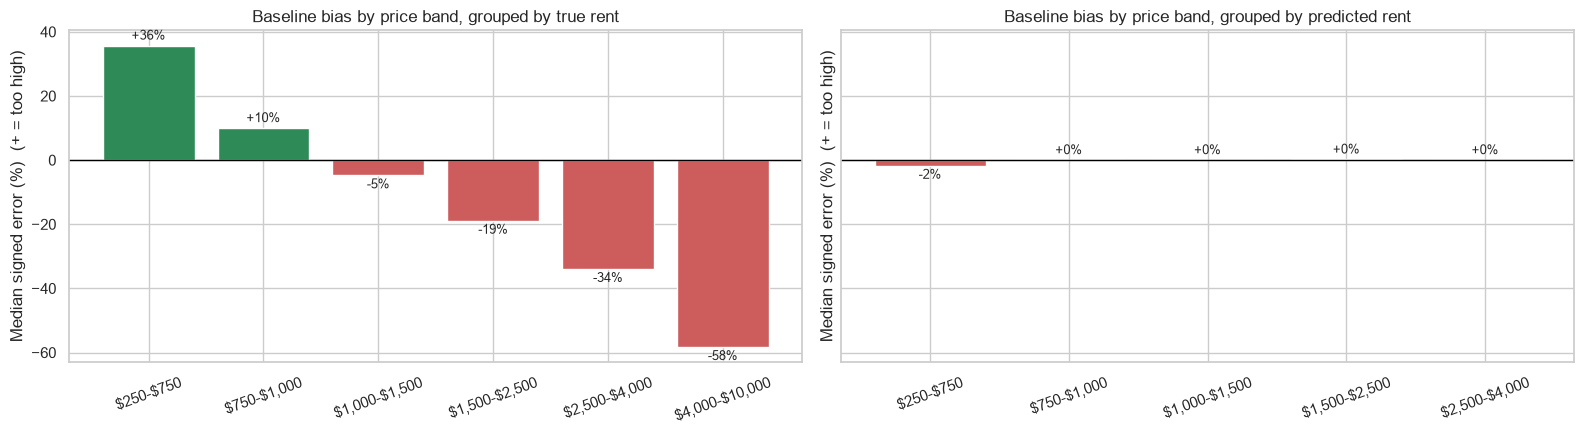

True-band bias: cheapest band +35.7%, most expensive band -58.2%
Largest bias by predicted band (100+ listings): $250-$750 (-1.7%, 7,819 listings)


In [13]:
# 11.3 Baseline errors by true and by predicted price band

def error_table(groups):
    t = train.groupby(groups, observed=True).agg(
        listings=("price", "size"),
        median_rent=("price", "median"),
        bias_pct=("err_pct", "median"),
        median_abs_pct=("err_pct", lambda s: s.abs().median()),
        MAE=("abs_err", "mean"))
    t["share_%"] = t["listings"] / len(train) * 100
    return t[["listings", "share_%", "median_rent", "bias_pct", "median_abs_pct", "MAE"]]

err_fmt = {"listings": "{:,}", "share_%": "{:.1f}%", "median_rent": "${:,.0f}", "bias_pct": "{:+.1f}%",
           "median_abs_pct": "{:.1f}%", "MAE": "${:,.0f}"}

by_true = error_table(train["price_band"])
by_pred = error_table(price_band(train["pred"]).rename("predicted_band"))
print("Grouped by TRUE rent band:")
display(by_true.style.format(err_fmt))
print("Grouped by PREDICTED rent band:")
display(by_pred.style.format(err_fmt))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)
for ax, t, title in [(axes[0], by_true, "grouped by true rent"), (axes[1], by_pred, "grouped by predicted rent")]:
    ax.bar([str(b).replace("$", r"\$") for b in t.index], t["bias_pct"], color=["seagreen" if v >= 0 else "indianred" for v in t["bias_pct"]])
    for i, v in enumerate(t["bias_pct"]):
        ax.text(i, v + (1 if v >= 0 else -1), f"{v:+.0f}%", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    ax.axhline(0, color="black", linewidth=1)
    ax.set(title=f"Baseline bias by price band, {title}", ylabel="Median signed error (%)  (+ = too high)")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
save_fig("11_baseline_bias_by_band")
plt.show()

top_true_bias, low_true_bias = by_true["bias_pct"].iloc[-1], by_true["bias_pct"].iloc[0]
worst_pred_band = by_pred.loc[by_pred["listings"] >= 100, "bias_pct"].abs().idxmax()   # ignore bands with < 100 listings
print(f"True-band bias: cheapest band {low_true_bias:+.1f}%, most expensive band {top_true_bias:+.1f}%")
print(f"Largest bias by predicted band (100+ listings): {worst_pred_band} ({by_pred.loc[worst_pred_band, 'bias_pct']:+.1f}%, "
      f"{by_pred.loc[worst_pred_band, 'listings']:,} listings)")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.3 Findings – error by price band

**Grouped by true rent: a strong pull towards the middle.**

| True band | Bias | Median abs error | MAE |
|---|---|---|---|
| $250–$750 | **+35.7%** | 35.7% | $272 |
| $750–$1,000 | +10.0% | 14.2% | $175 |
| $1,000–$1,500 | −4.7% | 14.3% | $212 |
| $1,500–$2,500 | −18.9% | 21.9% | $441 |
| $2,500–$4,000 | −33.9% | 33.9% | $1,068 |
| $4,000–$10,000 | **−58.2%** | 58.2% | **$3,133** |

- The baseline **over-predicts cheap homes and under-predicts expensive ones**; a home renting for about $4,900 is typically predicted at about $2,000.
- The errors are smallest in the busy middle bands (about 14%) and grow steadily towards both ends. That's **regression to the mean**: the baseline knows only the typical rent of the region, so anything unusual gets pulled back to it.
- **The baseline can't predict above $4,000 at all**: there is no "$4,000+" row in the predicted-band table, because even the most expensive region median (Santa Barbara, about $2,900) is below it. Only a model that uses size, amenities and precise location can reach the top band.

**Grouped by predicted rent: almost no bias** (−1.7% to +0.2% in every band) and a nearly constant typical error of **18–21%**. That's expected: a region median is by definition "right on average" for its region. **It's also the target for the real models:** when the model says $X, it should be neither systematically high nor low.

**Decision:** evaluate the final model **both ways**. By true band, the slope should become much **flatter** than the baseline's +36% … −58%. By predicted band, the bias should stay near 0. Sample weights are only a fallback if the top-band errors remain unacceptable.

> **Viva point:** "Grouping errors by the true value always shows regression to the mean for an imperfect model, because extreme rents are partly extreme for reasons the data doesn't record. That's why we also group by the *predicted* value, which is what a user of the platform experiences."

## 11.4 Rare categories and rare homes

**What this cell does:** two tables.

**Table 1 – every category of `type`, `laundry_options` and `parking_options`,** with:

- **listings** and **share** in the training set;
- **per CV fold:** about how many listings of that category the model sees when it learns from 4 of the 5 folds (80%). This is what matters for training, and it's compared with `RARE_MIN_COUNT` (50, the Step 9 rule) to confirm every category keeps its own column in **every** fold;
- **baseline bias:** the location-only baseline's median signed error for listings of that category. Since the baseline ignores the category, this is (roughly) **the category's own effect that a model still has to learn**. For example, if valet-parking listings show −30%, a model must learn a +30% valet premium from only about 86 examples per fold.

**Table 2 – rare kinds of homes** defined by numbers rather than categories: studios, 5+ bedrooms, 4+ bathrooms, over 3,000 sq ft, EV charging, and furnished homes. Same columns.

**Why:** a category or kind of home that is **both rare and far from the baseline** is where predictions will be least reliable: the model must learn a large effect from few examples. A rare category that sits near the baseline is harmless: even if the model learns little about it, it doesn't lose much.

**How to read the output:** look for rows with **few listings and a large bias**. These go on the list of groups the final evaluation reports separately (11.7).

In [14]:
# 11.4 Rare categories and rare kinds of homes

cat_rows = []
for col in ["type", "laundry_options", "parking_options"]:
    for value, g in train.groupby(col):
        cat_rows.append({"feature": col, "value": value, "listings": len(g),
                         "share_%": len(g) / len(train) * 100,
                         "per_CV_fold": len(g) * 0.8,
                         "baseline_bias_%": g["err_pct"].median()})
cats = pd.DataFrame(cat_rows).sort_values(["feature", "listings"]).set_index(["feature", "value"])
cats["own_column_every_fold"] = np.where(cats["per_CV_fold"] >= RARE_MIN_COUNT, "yes", "NO")
cats["rare (<1%)"] = np.where(cats["share_%"] < RARE_MIN_SHARE * 100, "rare", "")
display(cats.style.format({"listings": "{:,}", "share_%": "{:.2f}%", "per_CV_fold": "{:,.0f}",
                           "baseline_bias_%": "{:+.1f}%"}))

homes = {
    "studio (0 beds)": train["beds"].eq(0),
    "5+ bedrooms": train["beds"].ge(5),
    "4+ bathrooms": train["baths"].ge(4),
    "over 3,000 sq ft": train["sqfeet"].gt(3000),
    "EV charging": train["electric_vehicle_charge"].eq(1),
    "furnished": train["comes_furnished"].eq(1),
}
home_rows = [{"kind of home": k, "listings": int(m.sum()), "share_%": m.mean() * 100,
              "per_CV_fold": m.sum() * 0.8, "median_rent": train.loc[m, "price"].median(),
              "baseline_bias_%": train.loc[m, "err_pct"].median()} for k, m in homes.items()]
rare_homes = pd.DataFrame(home_rows).set_index("kind of home")
display(rare_homes.style.format({"listings": "{:,}", "share_%": "{:.2f}%", "per_CV_fold": "{:,.0f}",
                                 "median_rent": "${:,.0f}", "baseline_bias_%": "{:+.1f}%"}))

rare_cats = cats[cats["rare (<1%)"] == "rare"]
all_have_column = bool((cats["own_column_every_fold"] == "yes").all())
risky = pd.concat([rare_cats["baseline_bias_%"].set_axis([f"{c}={v}" for c, v in rare_cats.index]),
                   rare_homes.loc[rare_homes["share_%"] < 2, "baseline_bias_%"]])
risky = risky[risky.abs() >= 15].sort_values()
print(f"Every category keeps its own column in every CV fold: {all_have_column}")
print("Rare groups (< 1% categories, < 2% kinds of homes) with a baseline bias of 15% or more: "
      + (", ".join(f"{k} {v:+.0f}%" for k, v in risky.items()) or "none"))

,listings,share_%,per_CV_fold,median_rent,baseline_bias_%
kind of home,,,,,
studio (0 beds),"4,347",2.89%,"3,478","$1,035",+27.0%
5+ bedrooms,"1,684",1.12%,"1,347","$1,500",-33.3%
4+ bathrooms,644,0.43%,515,"$1,850",-34.1%
"over 3,000 sq ft",735,0.49%,588,"$2,700",-52.4%
EV charging,"2,916",1.94%,"2,333","$1,685",-11.4%
furnished,"8,350",5.55%,"6,680","$1,200",-3.4%


Every category keeps its own column in every CV fold: True
Rare groups (< 1% categories, < 2% kinds of homes) with a baseline bias of 15% or more: over 3,000 sq ft -52%, 4+ bathrooms -34%, 5+ bedrooms -33%, parking_options=valet parking -24%, type=loft -16%, type=in-law +25%


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.4 Findings – rare categories and rare homes

- **Every category keeps its own one-hot column in every CV fold** (`RARE_MIN_COUNT = 50`). The smallest, valet parking, still has about **86** listings per learning fold.
- **Baseline bias per category**, which is roughly the category's own effect that a model still has to learn:
  - **Garages and in-unit laundry push rent up** (attached garage −20.5%, w/d in unit −9.5%: the baseline predicts too low for them).
  - **Basic amenities push rent down** (no laundry on site +38.2%, laundry on site +18.6%: the baseline predicts too high).
  - **"missing"** laundry (+4.4%) and parking (+2.2%) sit close to zero: blanks behave like average listings, which supports the `"missing"` category (Step 3).

**Rare groups with a large bias (≥ 15%)**, where predictions will be least reliable:

| Group | Listings | Baseline bias |
|---|---|---|
| over 3,000 sq ft | 735 | **−52.4%** |
| 4+ bathrooms | 644 | −34.1% |
| 5+ bedrooms | 1,684 | −33.3% |
| valet parking | 108 | −23.9% |
| in-law unit | 134 | **+24.9%** |
| loft | 366 | −15.7% |

- **Large, luxury homes are the biggest risk:** they're rare *and* far from their region's typical rent.
- **In-law units** are cheaper than their region's typical rent (small units attached to a house).
- **Studios** (+27.0%, 4,347 listings) aren't rare, but the baseline over-predicts them, as Step 10.4 predicted.

**Decision:** these groups are reported separately in the final evaluation (`error_analysis_plan.csv`). No change to the encoding.

## 11.5 Geographic imbalance

**What this cell does, in three parts:**

1. **How concentrated are the listings?** It draws a **Lorenz curve**: regions sorted from smallest to largest across the bottom, and the cumulative share of listings they hold up the side.
   - If every region had the same number of listings, the curve would follow the **diagonal**.
   - The further the curve sags below the diagonal, the more the listings are concentrated in a few large regions.
   - The **Gini coefficient** summarises this in one number: **0** = perfectly even, **1** = all listings in one region. (It's the same measure economists use for income inequality.) It also reports the share of listings held by the largest 10% of regions.
2. **Does the baseline get worse in small regions?** Errors by **region size band** (under 30, 30–99, 100–499, 500+ training listings).
3. **The 10 regions with the largest typical error** (among regions with 30+ listings, so a few odd listings can't dominate).

**Why:** a small region gives the model few local examples. The baseline's region median is then built from, say, 3 or 4 listings in the learning folds, and its errors show how much that hurts. Real models have extra help (state, coordinates, the Step 10.5 state-level smoothing), and **the final evaluation will show whether they close this gap**.

**How to read the output:**

- **Gini** around 0.3–0.4 = moderately uneven; above 0.5 = strongly concentrated.
- **Median absolute % error rising** from the 500+ band to the under-30 band = predictions are less reliable in thinly covered places, which is a limitation to report and a check for the final model.
- **The worst regions** often show *why* errors are high: very mixed markets (a region covering both an expensive resort and cheap rural towns), or the college towns from Step 10.7.

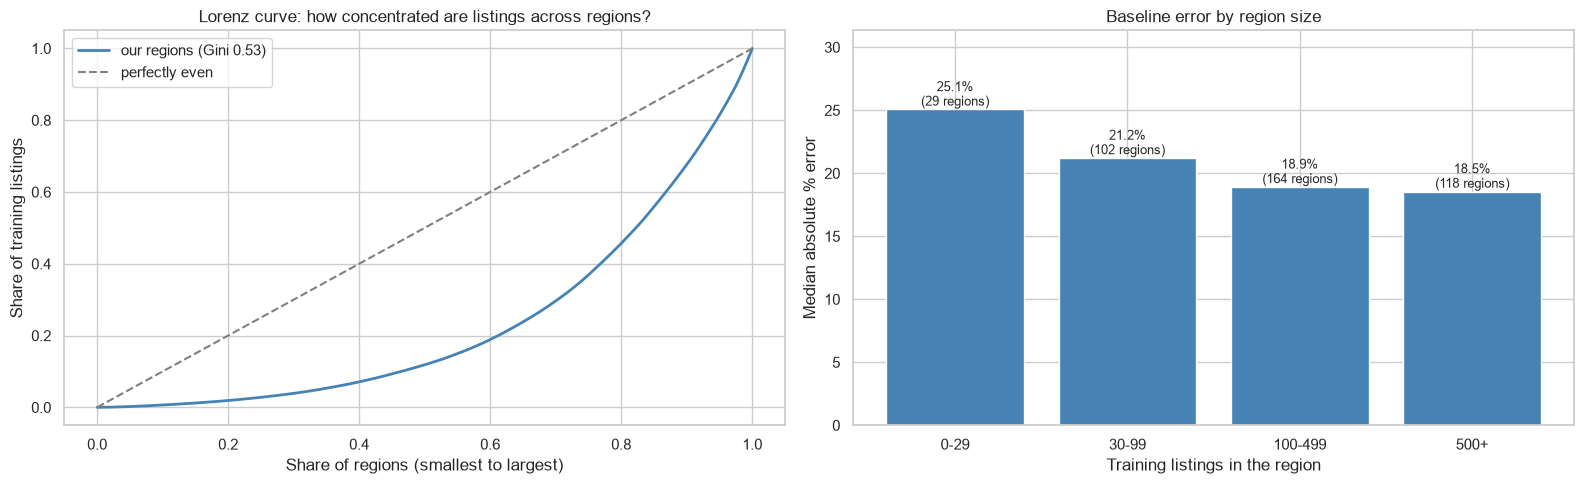

Gini coefficient of listings across regions: 0.53; the largest 10% of regions hold 32.8% of listings


,listings,regions,share_%,median_rent,bias_pct,median_abs_pct,MAE
region_band,,,,,,,
0-29,556,29,0.4%,$840,+0.3%,25.1%,$257
30-99,"5,969",102,4.0%,$875,+0.0%,21.2%,$257
100-499,"40,880",164,27.2%,$960,-0.0%,18.9%,$282
500+,"102,999",118,68.5%,"$1,239",+0.0%,18.5%,$336


Regions (30+ listings) with the largest typical baseline error:


,listings,median_rent,median_abs_pct
region_url,,,
clovis,39,$800,41.4%
scottsbluff,50,"$1,385",39.8%
roswell,31,"$1,595",37.7%
gadsden,51,$950,35.7%
morgantown,122,$975,35.2%
palmsprings,592,"$1,675",34.0%
northplatte,34,"$1,146",32.0%
up,63,$725,31.1%
rockies,181,"$1,900",30.8%


In [15]:
# 11.5 Geographic imbalance: concentration, error by region size, worst regions

sizes = np.sort(region_counts.to_numpy())
cum_listings = np.insert(np.cumsum(sizes) / sizes.sum(), 0, 0)
cum_regions = np.linspace(0, 1, len(cum_listings))
_trapz = getattr(np, "trapezoid", None) or np.trapz          # the name differs between NumPy 1.x and 2.x
gini = 1 - 2 * _trapz(cum_listings, cum_regions)
top10_share = region_counts.head(int(np.ceil(len(region_counts) * 0.10))).sum() / len(train) * 100

by_region_band = error_table(train["region_band"])
by_region_band.insert(1, "regions", train.groupby("region_band", observed=True)["region_url"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(cum_regions, cum_listings, color="steelblue", linewidth=2, label=f"our regions (Gini {gini:.2f})")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--", label="perfectly even")
axes[0].set(xlabel="Share of regions (smallest to largest)", ylabel="Share of training listings",
            title="Lorenz curve: how concentrated are listings across regions?")
axes[0].legend()

axes[1].bar(by_region_band.index.astype(str), by_region_band["median_abs_pct"], color="steelblue")
for i, (v, n) in enumerate(zip(by_region_band["median_abs_pct"], by_region_band["regions"])):
    axes[1].text(i, v + 0.3, f"{v:.1f}%\n({n} regions)", ha="center", fontsize=9)
axes[1].set(xlabel="Training listings in the region", ylabel="Median absolute % error",
            title="Baseline error by region size", ylim=(0, by_region_band["median_abs_pct"].max() * 1.25))
plt.tight_layout()
save_fig("11_geographic_imbalance")
plt.show()

print(f"Gini coefficient of listings across regions: {gini:.2f}; the largest 10% of regions hold {top10_share:.1f}% of listings")
display(by_region_band.style.format({**err_fmt, "regions": "{:,}"}))

region_err = train.groupby("region_url").agg(listings=("price", "size"), median_rent=("price", "median"),
                                             median_abs_pct=("err_pct", lambda s: s.abs().median()))
worst = region_err[region_err["listings"] >= 30].sort_values("median_abs_pct", ascending=False).head(10)
worst.index = worst.index.map(short_region)
print("Regions (30+ listings) with the largest typical baseline error:")
display(worst.style.format({"listings": "{:,}", "median_rent": "${:,.0f}", "median_abs_pct": "{:.1f}%"}))

small_err = by_region_band["median_abs_pct"].iloc[0]
large_err = by_region_band["median_abs_pct"].iloc[-1]

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.5 Findings – geographic imbalance

- **Listings are concentrated:** Gini **0.53** (strongly uneven), and the largest 10% of regions hold **32.8%** of all training listings.
- **Error grows as regions get smaller:**

| Region size | Regions | Listings | Median abs error |
|---|---|---|---|
| under 30 | 29 | 556 | **25.1%** |
| 30–99 | 102 | 5,969 | 21.2% |
| 100–499 | 164 | 40,880 | 18.9% |
| 500+ | 118 | 102,999 | **18.5%** |

  Small regions have 6.6 percentage points more error than the biggest ones. It's a clear but modest effect, and it affects only **4.3%** of listings (regions under 100).
- **The worst regions** (30+ listings) are mostly **mixed markets**, where one region contains very different kinds of places:
  - resort areas next to ordinary towns: **Palm Springs** (34.0%), **Rockies** (ski towns + rural, 30.8%), **Santa Fe** (30.8%);
  - small, rural regions: Clovis (41.4%), Scottsbluff (39.8%), Roswell (37.7%), Gadsden, North Platte, Michigan's Upper Peninsula ("up");
  - a college town: **Morgantown** (West Virginia University, 35.2%).

  In mixed markets a single regional median can't describe everyone; **coordinates** (which trees can use to find the resort vs the town) should help most here.

**Decision:** report error by region size band; the state-level smoothing (Step 10.5) targets the smallest regions. Report as a limitation: *"predictions are less reliable in regions with few listings and in mixed resort/rural markets."*

## 11.6 Student-layout homes

**What this cell does:** it compares the baseline's errors for **student-layout homes** (4+ bedrooms with a bathroom per bedroom, `student_layout()` in `utils.py`) with all other homes, and with other homes that have **4+ bedrooms** (a fairer comparison, since large homes are unusual anyway). It also shows how these homes are split across the price bands.

**Why:** Step 10.7 found that many of these listings show the **price of one room** (median $830 for a 4-bed/4-bath home). A model that has learnt "more bedrooms and bathrooms → higher rent" will **over-predict** them, perhaps by a lot. The baseline doesn't use beds or baths, so its error here mostly shows how far these rents sit from their region's typical rent.

**Why the definition uses only beds and baths:** at prediction time, the platform knows the beds and baths the user enters, but not the rent (that's what it predicts). A group definition that used rent per square foot (as 10.7 did to find the suspects) could be used for analysis but never as a feature. This definition can be both: a **group for error analysis** and, if it helps, a **model feature** (Step 10.7's idea).

**How to read the output:**

- **A large positive baseline bias** for the student group (the baseline predicts **too high**, because these listings are far *cheaper* than their region's median), while other 4+ bedroom homes show a negative bias (they are *dearer* than their region's median, as large homes should be), confirms these rents behave differently.
- **Most of them in the cheaper bands** despite being 4+ bedroom homes = consistent with per-room pricing.
- The final evaluation will report this group separately, and the report should state it as a known limitation: *"for 4+ bedroom homes with a bathroom per bedroom, especially in college towns, advertised rents are often per room; our predictions for such homes should be read with caution."*

In [16]:
# 11.6 Student-layout homes vs other homes

groups = np.select([train["student"], train["beds"].ge(STUDENT_LAYOUT_MIN_BEDS)],
                   ["student layout (4+ beds, baths >= beds)", "other 4+ bedroom homes"], default="all other homes")
student_tab = error_table(pd.Series(groups, index=train.index, name="group"))
display(student_tab.style.format(err_fmt))

band_mix = pd.crosstab(pd.Series(groups, index=train.index, name="group"), train["price_band"], normalize="index") * 100
print("Share of each group's listings in each price band (%):")
display(band_mix.style.format("{:.1f}%"))

student_bias = student_tab.loc["student layout (4+ beds, baths >= beds)", "bias_pct"] if train["student"].any() else np.nan
other4_bias = student_tab.loc["other 4+ bedroom homes", "bias_pct"] if "other 4+ bedroom homes" in student_tab.index else np.nan
student_top_region = train.loc[train["student"], "region_url"].map(short_region).value_counts().head(5)
print("Regions with the most student-layout homes: "
      + ", ".join(f"{k} ({v})" for k, v in student_top_region.items()))

,listings,share_%,median_rent,bias_pct,median_abs_pct,MAE
group,,,,,,
all other homes,"142,636",94.8%,"$1,130",+0.9%,18.1%,$295
other 4+ bedroom homes,"7,326",4.9%,"$1,500",-28.9%,33.5%,$713
"student layout (4+ beds, baths >= beds)",442,0.3%,$849,+29.2%,59.8%,"$1,112"


Share of each group's listings in each price band (%):


price_band,$250-$750,"$750-$1,000","$1,000-$1,500","$1,500-$2,500","$2,500-$4,000","$4,000-$10,000"
group,,,,,,
all other homes,15.2%,25.1%,34.8%,20.5%,3.8%,0.6%
other 4+ bedroom homes,6.0%,14.1%,30.7%,33.1%,12.8%,3.3%
"student layout (4+ beds, baths >= beds)",46.2%,7.9%,6.3%,10.9%,18.1%,10.6%


Regions with the most student-layout homes: sanmarcos (38), gainesville (34), tallahassee (26), denver (14), tippecanoe (12)


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.6 Findings – student-layout homes

| Group | Listings | Median rent | Baseline bias | Median abs error |
|---|---|---|---|---|
| all other homes | 142,636 | $1,130 | +0.9% | 18.1% |
| other 4+ bedroom homes | 7,326 | $1,500 | **−28.9%** | 33.5% |
| student layout | 442 | **$849** | **+29.2%** | **59.8%** |

- **They behave in the opposite direction to other large homes.** Ordinary 4+ bedroom homes rent for *more* than their region's typical rent (the baseline is 29% too low), while student-layout homes rent for *less* (the baseline is 29% too high), and their typical error is **59.8%**, the worst of any group.
- **They're a mix of two different things.** The band mix shows it: **46.2%** are in the cheapest band ($250–$750), consistent with **per-room prices**, but **28.7%** are above $2,500 (10.6% above $4,000): genuine **large luxury homes** with many bathrooms. The same beds/baths pattern can mean "one room in a student flat" or "a big expensive house".
- **Where:** San Marcos (38), Gainesville (34), Tallahassee (26), Denver (14), Tippecanoe (12), mostly university towns, as in Step 10.7.

**Decision:**
- Keep this as a **separate error-analysis group** and a **limitation** in the report.
- The **indicator feature** (4+ beds, baths ≥ beds) is still worth testing, but on its own it can't tell the two kinds apart: the model needs it **together with location and size** (a student flat in Gainesville vs a large house in Denver). Tree models can combine these; that's a point to check when comparing models.

## 11.7 The error-analysis plan for the final evaluation

**What this cell does:** it collects every group this step found into **one table**: the group, how it's defined, how many training listings it has, and the baseline's typical error. This table is the **plan for Step 14**, when the final model is evaluated once on the test set: the same groups (defined by the same `utils.py` functions) will be reported there, next to the overall score.

**Why a plan now, and not later?** If we choose the groups *after* seeing the test results, it's tempting to pick the ones that make the model look good (a subtle form of data snooping). Fixing them **before** the final evaluation keeps the evaluation honest. It's the same reason the test set was locked in Step 7.

**How to read the output:** each row is a promise: *"the final report will show the model's error for this group"*. Groups with a large baseline error are the ones where the real model needs to show the biggest improvement.

In [17]:
# 11.7 Error-analysis groups for the final evaluation (Step 14)

plan_rows = []
for band, r in by_true.iterrows():
    plan_rows.append({"group": f"true rent {band}", "definition": "price_band(price)",
                      "listings": r["listings"], "baseline_median_abs_%": r["median_abs_pct"], "baseline_bias_%": r["bias_pct"]})
for band, r in by_pred.iterrows():
    plan_rows.append({"group": f"predicted rent {band}", "definition": "price_band(prediction)",
                      "listings": r["listings"], "baseline_median_abs_%": r["median_abs_pct"], "baseline_bias_%": r["bias_pct"]})
for band, r in by_region_band.iterrows():
    plan_rows.append({"group": f"region with {band} training listings", "definition": "region_size_band(region, train counts)",
                      "listings": r["listings"], "baseline_median_abs_%": r["median_abs_pct"], "baseline_bias_%": r["bias_pct"]})
for g, r in student_tab.iterrows():
    if g != "all other homes":
        plan_rows.append({"group": g, "definition": "student_layout(df) / beds >= 4",
                          "listings": r["listings"], "baseline_median_abs_%": r["median_abs_pct"], "baseline_bias_%": r["bias_pct"]})
for (col, value), r in rare_cats.iterrows():
    g = train[train[col] == value]
    plan_rows.append({"group": f"{col} = {value}", "definition": "rare category (< 1%)", "listings": r["listings"],
                      "baseline_median_abs_%": g["err_pct"].abs().median(), "baseline_bias_%": r["baseline_bias_%"]})

plan = pd.DataFrame(plan_rows).set_index("group")
plan.to_csv(REPORT_DIR / "error_analysis_plan.csv")
display(plan.style.format({"listings": "{:,.0f}", "baseline_median_abs_%": "{:.1f}%", "baseline_bias_%": "{:+.1f}%"}))
print(f"Saved to {REPORT_DIR / 'error_analysis_plan.csv'} ({len(plan)} groups)")

,definition,listings,baseline_median_abs_%,baseline_bias_%
group,,,,
true rent $250-$750,price_band(price),"22,299",35.7%,+35.7%
"true rent $750-$1,000",price_band(price),"36,877",14.2%,+10.0%
"true rent $1,000-$1,500",price_band(price),"51,954",14.3%,-4.7%
"true rent $1,500-$2,500",price_band(price),"31,726",21.9%,-18.9%
"true rent $2,500-$4,000",price_band(price),"6,444",33.9%,-33.9%
"true rent $4,000-$10,000",price_band(price),"1,104",58.2%,-58.2%
predicted rent $250-$750,price_band(prediction),"7,819",18.4%,-1.7%
"predicted rent $750-$1,000",price_band(prediction),"49,602",18.4%,+0.0%
"predicted rent $1,000-$1,500",price_band(prediction),"65,375",18.8%,+0.0%


Saved to C:\Projects\FDM Project\fdm-rental-price\reports\error_analysis_plan.csv (23 groups)


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.7 Findings – the error-analysis plan

**23 groups** are fixed and saved in `reports/error_analysis_plan.csv`: 6 true-rent bands, 5 predicted-rent bands (the baseline never predicts $4,000+), 4 region-size bands, 2 large-home groups and 6 rare categories. The baseline's error for each is recorded next to it.

The groups with the **largest baseline errors**, where the real models must show the biggest improvement:
- **true rent $4,000+** (58.2%) and **$250–$750** (35.7%);
- **student layout** (59.8%) and **other 4+ bedroom homes** (33.5%);
- **valet parking** (29.7%) and **cottage/cabin** (28.8%);
- **regions with under 30 listings** (25.1%).

Fixing these groups **before** the final evaluation keeps it honest: we can't pick flattering groups after seeing the test results.

## 11.8 Log the Step 11 observations

As in every step, `clear_obs("11")` removes older Step 11 entries, and every sentence is built from your results with if/else wording, so the log always matches the outputs above. (With the corrected `clear_obs` from Step 10, `"11"` only matches Step 11, not Step 1.)

In [18]:
# 11.8 Log the observations

STEP = "11-Imbalance"
clear_obs("11")

log_obs(STEP,
        "Listings per price band: " + ", ".join(f"{b} {s:.1f}%" for b, s in bands["share_%"].items())
        + f"; busiest band has {band_ratio:.0f}x the listings of the emptiest; skew {train['price'].skew():.2f} "
        f"in dollars vs {train['log_price'].skew():.2f} on the log scale",
        "11.1 band table, bar chart and log histogram",
        "Keep the natural population (no oversampling or weighting); model log1p(price); "
        "report every final metric per price band")

log_obs(STEP,
        f"Location-only baseline (region median, GroupKFold 5, out-of-fold): MAE ${baseline['MAE_$']:,.0f}, "
        f"RMSE ${baseline['RMSE_$']:,.0f}, median abs error {baseline['median_abs_%_error']:.1f}%, "
        f"R2 on log rent {baseline['R2_log']:.3f}",
        "11.2 baseline table; reports/baseline_location_only.csv",
        "Every model must clearly beat this baseline under the same grouped cross-validation")

log_obs(STEP,
        f"Baseline bias by true band: {low_true_bias:+.1f}% (cheapest) to {top_true_bias:+.1f}% (most expensive); "
        f"largest bias by predicted band {worst_pred_band} "
        f"({by_pred.loc[worst_pred_band, 'bias_pct']:+.1f}%)",
        "11.3 bias charts and tables",
        ("Strong regression to the mean in the tails: " if abs(top_true_bias) >= 20 else "Moderate pull to the mean: ")
        + "evaluate by true AND predicted band; sample weights only as a fallback if top-band errors "
        "remain unacceptable")

log_obs(STEP,
        f"Every category keeps its own column in every CV fold: {all_have_column}; rare groups far from the "
        "baseline: " + (", ".join(f"{k} {v:+.0f}%" for k, v in risky.items()) or "none"),
        "11.4 category and rare-home tables",
        "Report these groups separately in the final evaluation; their estimates rest on few listings")

log_obs(STEP,
        f"Listings across regions: Gini {gini:.2f}, largest 10% of regions hold {top10_share:.1f}%; "
        f"baseline median abs error {small_err:.1f}% in the smallest region band vs {large_err:.1f}% in the largest",
        "11.5 Lorenz curve, error by region size, worst regions",
        ("Predictions are less reliable in thinly covered regions: " if small_err > large_err + 2 else
         "Region size has little effect on baseline error: ")
        + "report error by region size band; state-level smoothing (Step 10.5) targets small regions")

log_obs(STEP,
        f"Student-layout homes: {int(train['student'].sum()):,} listings, baseline bias {student_bias:+.1f}% "
        f"vs {other4_bias:+.1f}% for other 4+ bedroom homes",
        "11.6 group table and band mix",
        ("Behave differently from other large homes (per-room prices): " if abs(student_bias - other4_bias) >= 15 else
         "Only a modest difference from other large homes: ")
        + "separate error-analysis group; candidate indicator feature; limitation in the report")

log_obs(STEP,
        f"{len(plan)} error-analysis groups fixed before the final evaluation",
        "11.7 plan table; reports/error_analysis_plan.csv",
        "Step 14 reports the final model's error for exactly these groups, defined by the utils.py functions")

show_obs(11)

,step,observation,evidence,decision
0,11-Imbalance,"Listings per price band: $250-$750 14.8%, $750...","11.1 band table, bar chart and log histogram",Keep the natural population (no oversampling o...
1,11-Imbalance,"Location-only baseline (region median, GroupKF...",11.2 baseline table; reports/baseline_location...,Every model must clearly beat this baseline un...
2,11-Imbalance,Baseline bias by true band: +35.7% (cheapest) ...,11.3 bias charts and tables,Strong regression to the mean in the tails: ev...
3,11-Imbalance,Every category keeps its own column in every C...,11.4 category and rare-home tables,Report these groups separately in the final ev...
4,11-Imbalance,"Listings across regions: Gini 0.53, largest 10...","11.5 Lorenz curve, error by region size, worst...",Predictions are less reliable in thinly covere...
5,11-Imbalance,"Student-layout homes: 442 listings, baseline b...",11.6 group table and band mix,Behave differently from other large homes (per...
6,11-Imbalance,23 error-analysis groups fixed before the fina...,11.7 plan table; reports/error_analysis_plan.csv,Step 14 reports the final model's error for ex...


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 11.8 Findings – the log

Seven Step 11 entries were logged, and their adaptive wording matches the outputs:
- "Strong regression to the mean in the tails";
- "Predictions are less reliable in thinly covered regions";
- "Behave differently from other large homes (per-room prices)".

---

## Step 11 findings – what our data showed

1. **Target imbalance:** 95% of listings rent for $2,500 or less; only **0.7%** are in the $4,000+ band (47× fewer than the busiest band). The log target cuts skew from 2.70 to 0.39.
2. **The baseline to beat** (region median, grouped 5-fold CV): **MAE $318, RMSE $518, median abs error 18.8%, R² 0.468** on log rent.
3. **Regression to the mean:** by true band, the baseline's bias runs from **+35.7%** (cheapest) to **−58.2%** (most expensive), and it never predicts above $4,000. By predicted band it's unbiased (about 0%).
4. **Rare groups:** every category keeps its own column in every fold; the riskiest rare groups are homes over 3,000 sq ft (−52%), 4+ baths, 5+ beds, valet parking and in-law units.
5. **Geography:** listings are concentrated (Gini 0.53); error rises from 18.5% in the largest regions to 25.1% in the smallest, and is highest in mixed resort/rural markets.
6. **Student-layout homes** (442) are the worst group (59.8% typical error), a mix of per-room student lets (46% under $750) and large luxury homes (29% over $2,500).
7. **23 error-analysis groups** are fixed for the final evaluation.

**Decisions:**

| Decision | Evidence |
|---|---|
| No oversampling or weighting; log target; per-band reporting | 11.1, 11.3 |
| Every model must beat the baseline under the same grouped CV | 11.2 |
| Evaluate by **true and predicted** price band | 11.3 |
| Report rare groups, region-size bands and student layout separately | 11.4–11.7 |
| Student indicator only useful together with location and size | 11.6 |

> **Viva summary:** "In regression, imbalance means thinly covered parts of the target and feature space. We quantified it with a cross-validated location-only baseline: it's pulled strongly towards typical rents, can't predict above $4,000, and is weakest for luxury homes, small regions and per-room student lets. These groups, fixed in advance, are reported separately in the final evaluation."

---

## What's next: Step 12 – Data leakage audit

**Leakage** means the model gets information during training that it won't have when it's used for real, so its test score looks better than its real performance. Step 12 goes through every risk with evidence, in one table:

- **identifier columns** (`id`, `url`, `image_url`): they must never be features (they identify listings, and reposts can share them);
- **`description`:** some descriptions may **state the rent** ("$1,200/month"). We'll measure **what share of descriptions contain a dollar amount**, and whether it matches the price. Description is not a model feature, but it must not sneak in later;
- **duplicates across the split:** re-confirm Step 7's checks (identical listings and families never on both sides);
- **fitting on test data:** every learned step (imputation, target encoding, scaling) must be fitted inside the pipeline on training folds only;
- **target encoding of region:** must be **cross-fitted**, or each listing's own rent leaks into its encoded region value;
- **the student-layout indicator and price bands:** confirm they're computed from inputs only (beds, baths), or used only for evaluation (price bands).